# Meadowbrook Family Park-Feedback Analysis

Starter notebook for exploring visitor feedback collected via the feedback form.

Reads directly from `Backend/feedback.csv`. Re-run this notebook any time new submissions come in.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../Backend/feedback.csv", parse_dates=["date"])
df.head()

,date,guests,nationality,source,source_details,nature_trail,garden_walk,petting_zoo,family_games_area,fishing_pond,tea_rating,lunch_rating,suggestions
0,2025-12-16,2,German,Instagram,NaN,4,4,4,5,5,"Loved the tea tasting, very fresh.","Loved the variety, very fresh ingredients.",Better signage for directions around the farm.
1,2025-12-17,2,Dutch,Instagram,NaN,5,4,4,5,4,Excellent matcha and herbal blends!,Generous portions and tasty.,More shaded seating areas would help.
2,2025-12-17,3,Chinese,Tiktok,NaN,4,4,4,4,4,Best tea selection we have had on a farm tour.,Delicious vegetarian spread!,A map of the farm at the entrance would help.
3,2025-12-18,2,British,Tiktok,NaN,4,3,3,4,4,"Great variety, bought some to take home.","Good food, portions were a bit small.","Loved it, will recommend to friends!"
4,2025-12-21,1,Italian,Tiktok,NaN,4,4,4,4,4,"Loved the tea tasting, very fresh.","Loved the variety, very fresh ingredients.",Add a small gift shop for tea products.


## Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               61 non-null     datetime64[ns]
 1   guests             61 non-null     int64         
 2   nationality        61 non-null     object        
 3   source             61 non-null     object        
 4   source_details     7 non-null      object        
 5   nature_trail       61 non-null     int64         
 6   garden_walk        61 non-null     int64         
 7   petting_zoo        61 non-null     int64         
 8   family_games_area  61 non-null     int64         
 9   fishing_pond       61 non-null     int64         
 10  tea_rating         61 non-null     object        
 11  lunch_rating       61 non-null     object        
 12  suggestions        60 non-null     object        
dtypes: datetime64[ns](1), int64(6), object(6)
memory usage: 6.3+ KB


In [4]:
df.describe()

,date,guests,nature_trail,garden_walk,petting_zoo,family_games_area,fishing_pond
count,61,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,2026-03-12 06:41:18.688524544,3.901639,4.344262,3.983607,3.672131,3.885246,4.049180
min,2025-12-16 00:00:00,1.000000,3.000000,3.000000,3.000000,1.000000,1.000000
25%,2026-01-30 00:00:00,2.000000,4.000000,4.000000,3.000000,4.000000,4.000000
50%,2026-03-02 00:00:00,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,2026-05-04 00:00:00,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000
max,2026-06-12 00:00:00,10.000000,5.000000,5.000000,5.000000,5.000000,5.000000
std,NaN,2.681448,0.574028,0.532034,0.507323,0.685526,0.717083


## Average rating per activity

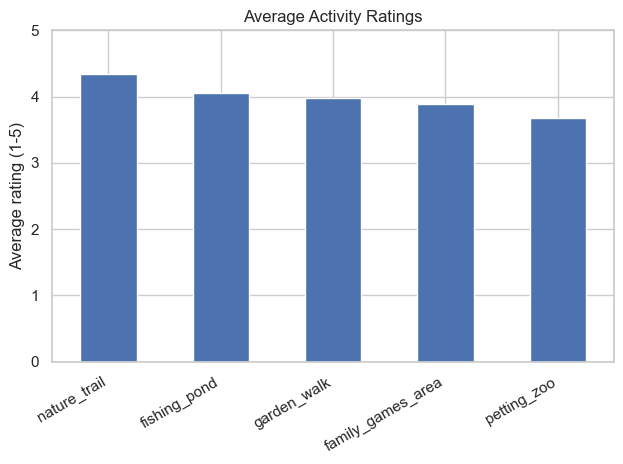

In [5]:
activity_cols = ["nature_trail", "garden_walk", "petting_zoo", "family_games_area", "fishing_pond"]
avg_ratings = df[activity_cols].mean().sort_values(ascending=False)

avg_ratings.plot(kind="bar", title="Average Activity Ratings", ylim=(0, 5))
plt.ylabel("Average rating (1-5)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## How visitors heard about us

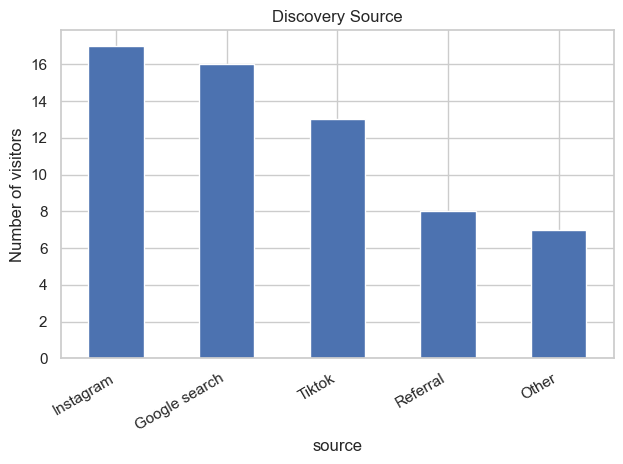

In [6]:
df["source"].value_counts().plot(kind="bar", title="Discovery Source")
plt.ylabel("Number of visitors")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Visitor nationality

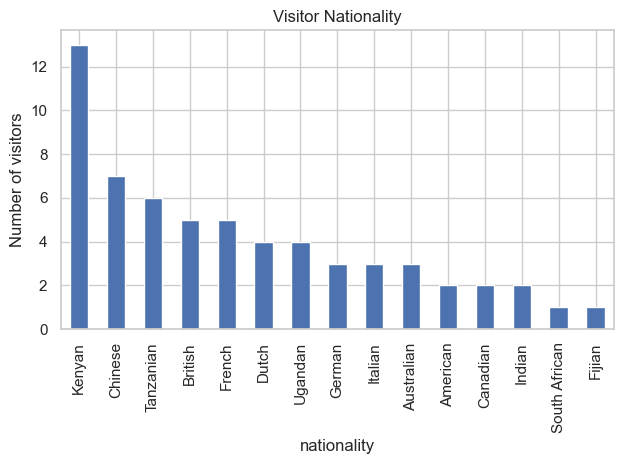

In [7]:
df["nationality"].value_counts().plot(kind="bar", title="Visitor Nationality")
plt.ylabel("Number of visitors")
plt.tight_layout()
plt.show()

## Group size over time

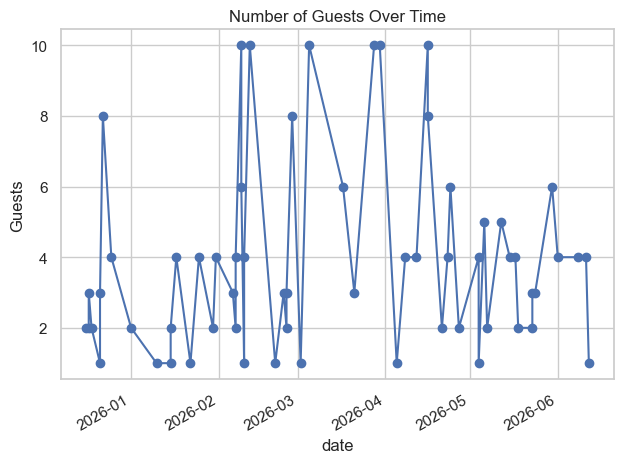

In [8]:
df.sort_values("date").plot(x="date", y="guests", marker="o", title="Number of Guests Over Time", legend=False)
plt.ylabel("Guests")
plt.tight_layout()
plt.show()

## Sentiment analysis of free-text feedback

The `tea_rating`, `lunch_rating`, and `suggestions` columns are free text, non-numeric ratings. Using VADER (a rule-based sentiment analyzer tuned for short, informal text), each comment gets a **compound sentiment score from -1 (very negative) to +1 (very positive)**, so they can be charted and compared like any other metric.

In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

text_cols = ["tea_rating", "lunch_rating", "suggestions"]
sentiment_cols = []
for col in text_cols:
    sentiment_col = f"{col}_sentiment"
    df[sentiment_col] = df[col].fillna("").apply(lambda text: analyzer.polarity_scores(text)["compound"])
    sentiment_cols.append(sentiment_col)

df[text_cols + sentiment_cols].head()

,tea_rating,lunch_rating,suggestions,tea_rating_sentiment,lunch_rating_sentiment,suggestions_sentiment
0,"Loved the tea tasting, very fresh.","Loved the variety, very fresh ingredients.",Better signage for directions around the farm.,0.7574,0.7574,0.4404
1,Excellent matcha and herbal blends!,Generous portions and tasty.,More shaded seating areas would help.,0.6114,0.5106,0.4019
2,Best tea selection we have had on a farm tour.,Delicious vegetarian spread!,A map of the farm at the entrance would help.,0.6369,0.6114,0.4019
3,"Great variety, bought some to take home.","Good food, portions were a bit small.","Loved it, will recommend to friends!",0.6249,0.4404,0.8687
4,"Loved the tea tasting, very fresh.","Loved the variety, very fresh ingredients.",Add a small gift shop for tea products.,0.7574,0.7574,0.4404


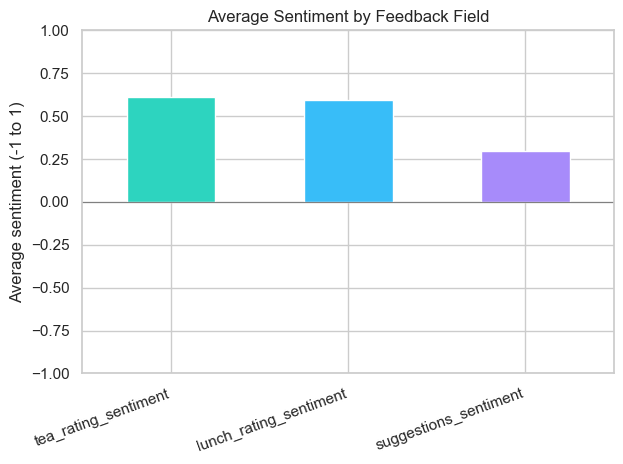

In [10]:
df[sentiment_cols].mean().plot(
    kind="bar", title="Average Sentiment by Feedback Field", ylim=(-1, 1),
    color=["#2dd4bf", "#38bdf8", "#a78bfa"],
)
plt.axhline(0, color="grey", linewidth=0.8)
plt.ylabel("Average sentiment (-1 to 1)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

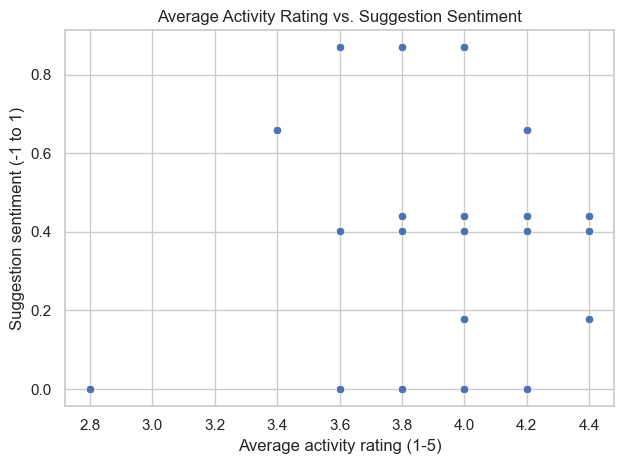

In [11]:
df["avg_activity_rating"] = df[activity_cols].mean(axis=1)

sns.scatterplot(data=df, x="avg_activity_rating", y="suggestions_sentiment")
plt.title("Average Activity Rating vs. Suggestion Sentiment")
plt.xlabel("Average activity rating (1-5)")
plt.ylabel("Suggestion sentiment (-1 to 1)")
plt.tight_layout()
plt.show()

In [12]:
# Lowest-sentiment suggestions, e.g. for follow-up
df.sort_values("suggestions_sentiment").head(5)[["date", "nationality", "suggestions", "suggestions_sentiment"]]

,date,nationality,suggestions,suggestions_sentiment
60,2026-06-12,Kenyan,NaN,0.0
25,2026-02-21,Indian,More frequent feeding sessions for the animals.,0.0
24,2026-02-12,French,Could use more shade near the animal pens.,0.0
38,2026-04-12,Ugandan,Could use more shade near the animal pens.,0.0
22,2026-02-10,British,Could use more shade near the animal pens.,0.0


## Next steps

- As more responses come in via the feedback form, just re-run this notebook to refresh all charts.
- Track sentiment trends over time (e.g. monthly average) as more volume comes in.
- Investigate the activity-rating vs. comment-sentiment mismatches (high rating, negative comment, or vice versa) for follow-up.